In [2]:
import sys
# Add the root folder where your notebook and mcp_client.py are located
sys.path.append("D:/Uni Stuff/Internships/AiGENThix/jonathan/python-notebook-mcp")

from server import initialize_workspace

Default workspace directory (uninitialized): d:\Uni Stuff\Internships\AiGENThix\jonathan


In [3]:
initialize_workspace(directory="D:/Uni Stuff/Internships/AiGENThix/jonathan/")

Workspace initialized at: D:/Uni Stuff/Internships/AiGENThix/jonathan/


'Workspace initialized at: D:/Uni Stuff/Internships/AiGENThix/jonathan/\nNotebooks found:\n- integrated-timeline.ipynb\n- integrated.ipynb\n- rule-mining.ipynb'

In [4]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from matplotlib.dates import DateFormatter, AutoDateLocator
from matplotlib import lines as mlines
import seaborn as sns
from datetime import datetime, timedelta
import warnings
warnings.filterwarnings('ignore')

from mlxtend.preprocessing import TransactionEncoder
from mlxtend.frequent_patterns import apriori, association_rules
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.cluster import KMeans
from sklearn.preprocessing import StandardScaler
from scipy.spatial.distance import cosine

pd.set_option('display.max_columns', None)
pd.set_option('display.max_rows', 190)
plt.style.use('seaborn-v0_8-darkgrid')

In [5]:
# Load data
df = pd.read_excel('cleaned_data.xlsx')

# Convert date column
df['Transaction Date'] = pd.to_datetime(df['Transaction Date'])

# Select and rename relevant columns
df = df[['Client number', 'Product Name', 'Product Type', 'Transaction Date', 
         'Transaction Amount (SGD)', 'Fund House/Issuer/Exchange', 
         'Product Category/DPMS Risk Level/Company Portfolio Risk Level']].copy()

df.columns = ['Client', 'Product', 'ProductType', 'Date', 'Amount', 'Issuer', 'Category']

# Sort by Client and Date
df = df.sort_values(['Client', 'Date']).reset_index(drop=True)

print(f" Data loaded: {len(df)} transactions")
print(f"   Date range: {df['Date'].min()} to {df['Date'].max()}")
print(f"   Unique clients: {df['Client'].nunique()}")
print(f"   Unique product types: {df['ProductType'].nunique()}")
print(f"\n Product Type Distribution:")
print(df['ProductType'].value_counts())

 Data loaded: 3171 transactions
   Date range: 2021-09-01 00:00:00 to 2025-09-26 00:00:00
   Unique clients: 190
   Unique product types: 5

 Product Type Distribution:
ProductType
STOCK    1805
ETF       463
UT        431
DPMS      264
BOND      208
Name: count, dtype: int64


DATASET OVERVIEW

 Shape: 3171 transactions × 7 columns

 Date Range: 2021-09-01 to 2025-09-26
   Duration: 1486 days

 Unique Clients: 190
 Unique Product Types: 5

 Transaction Amount Statistics (SGD):
count    3.171000e+03
mean     1.933195e+04
std      5.212408e+04
min      7.703000e+01
25%      2.655490e+03
50%      6.250000e+03
75%      1.859401e+04
max      1.000582e+06
Name: Amount, dtype: float64


[10/13/25 09:48:02] INFO     Using categorical units to plot a list of strings that are all         ]8;id=134895;file://d:\Programs\MiniConda\envs\AIML\lib\site-packages\matplotlib\category.py\category.py]8;;\:]8;id=607645;file://d:\Programs\MiniConda\envs\AIML\lib\site-packages\matplotlib\category.py#224\224]8;;\
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

                    INFO     Using categorical units to plot a list of strings that are all         ]8;id=202939;file://d:\Programs\MiniConda\envs\AIML\lib\site-packages\matplotlib\category.py\category.py]8;;\:]8;id=123156;file://d:\Programs\MiniConda\envs\AIML\lib\site-packages\matplotlib\category.py#224\224]8;;\
                             parsable as floats or dates. If these strings should be plotted as                    
                             numbers, cast to the appropriate data type before plotting.                           

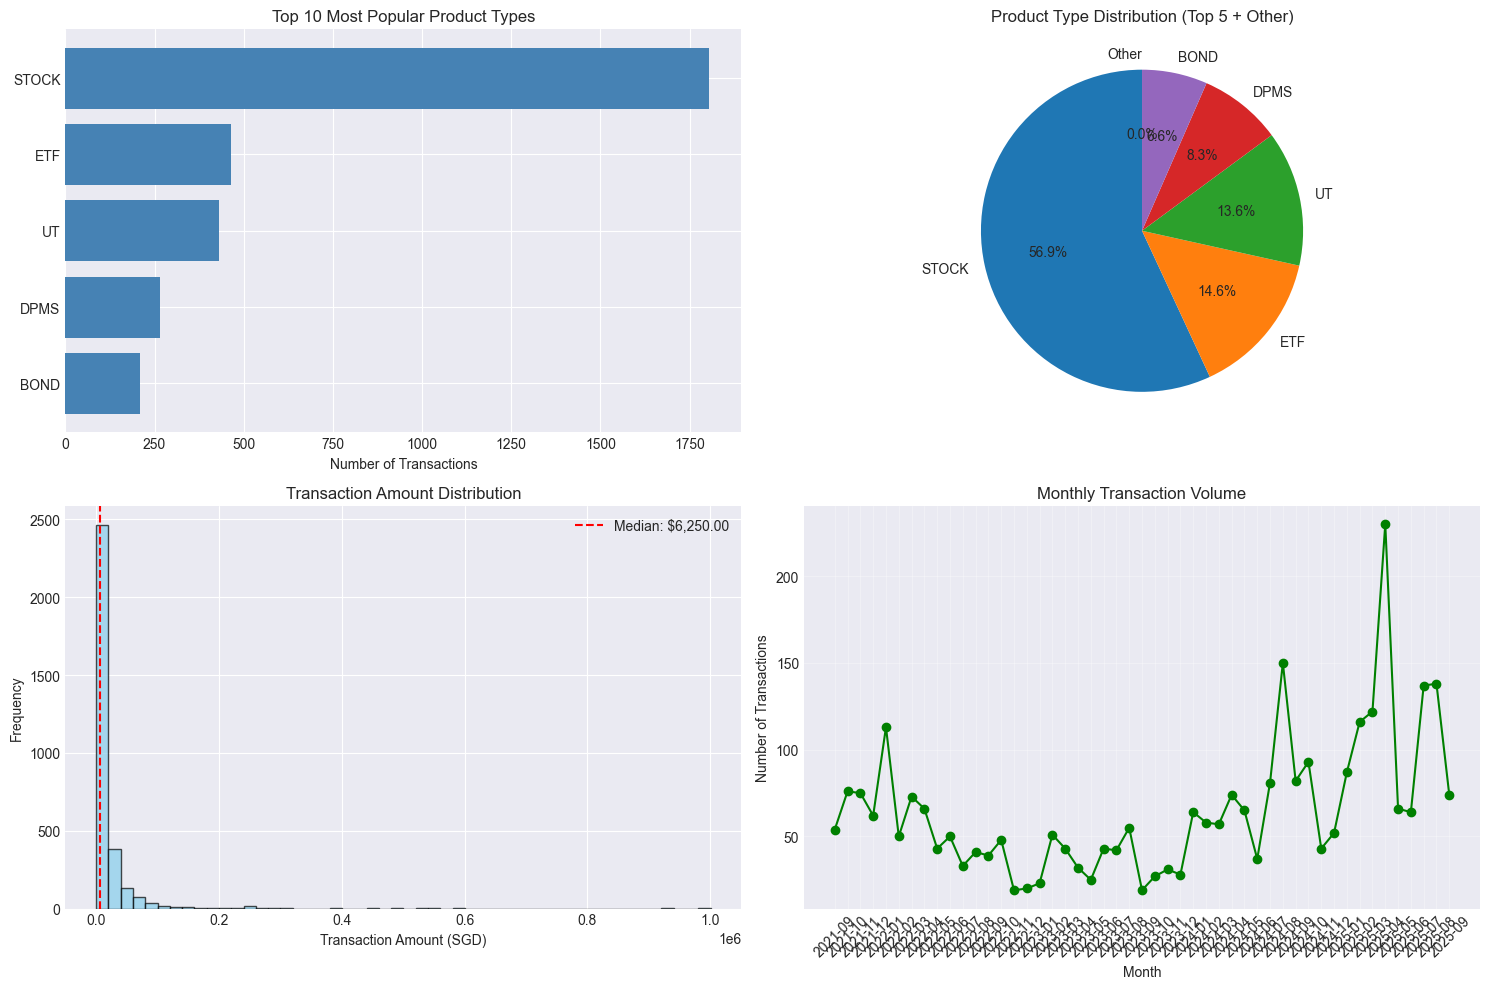


 EDA complete!


In [6]:
# Display basic statistics
print("=" * 60)
print("DATASET OVERVIEW")
print("=" * 60)
print(f"\n Shape: {df.shape[0]} transactions × {df.shape[1]} columns")
print(f"\n Date Range: {df['Date'].min().date()} to {df['Date'].max().date()}")
print(f"   Duration: {(df['Date'].max() - df['Date'].min()).days} days")
print(f"\n Unique Clients: {df['Client'].nunique()}")
print(f" Unique Product Types: {df['ProductType'].nunique()}")
print(f"\n Transaction Amount Statistics (SGD):")
print(df['Amount'].describe())

# Visualizations
fig, axes = plt.subplots(2, 2, figsize=(15, 10))

# Top 10 Product Types
product_type_counts = df['ProductType'].value_counts().head(10)
axes[0, 0].barh(product_type_counts.index, product_type_counts.values, color='steelblue')
axes[0, 0].set_xlabel('Number of Transactions')
axes[0, 0].set_title('Top 10 Most Popular Product Types')
axes[0, 0].invert_yaxis()

# Product Type Distribution (Pie)
top_5_types = df['ProductType'].value_counts().head(5)
other_count = df['ProductType'].value_counts()[5:].sum()
pie_data = pd.concat([top_5_types, pd.Series({'Other': other_count})])
axes[0, 1].pie(pie_data.values, labels=pie_data.index, autopct='%1.1f%%', startangle=90)
axes[0, 1].set_title('Product Type Distribution (Top 5 + Other)')

# Transaction Amount Distribution
axes[1, 0].hist(df['Amount'], bins=50, color='skyblue', edgecolor='black', alpha=0.7)
axes[1, 0].axvline(df['Amount'].median(), color='red', linestyle='--', 
                    label=f'Median: ${df["Amount"].median():,.2f}')
axes[1, 0].set_xlabel('Transaction Amount (SGD)')
axes[1, 0].set_ylabel('Frequency')
axes[1, 0].set_title('Transaction Amount Distribution')
axes[1, 0].legend()

# Monthly Transaction Volume
df['YearMonth'] = df['Date'].dt.to_period('M')
monthly_txns = df.groupby('YearMonth').size()
axes[1, 1].plot(monthly_txns.index.astype(str), monthly_txns.values, marker='o', color='green')
axes[1, 1].set_xlabel('Month')
axes[1, 1].set_ylabel('Number of Transactions')
axes[1, 1].set_title('Monthly Transaction Volume')
axes[1, 1].tick_params(axis='x', rotation=45)
axes[1, 1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

print("\n EDA complete!")

In [7]:
# Calculate client-level features
print(" Engineering client-level features...")

client_features = df.groupby('Client').agg({
    'Amount': ['mean', 'median', 'std', 'sum', 'count'],
    'Date': ['min', 'max'],
    'ProductType': lambda x: x.value_counts().index[0] if len(x) > 0 else None  # Most frequent
}).reset_index()

client_features.columns = ['Client', 'Avg_Amount', 'Median_Amount', 'Std_Amount', 
                           'Total_Invested', 'Num_Transactions', 'First_Transaction', 
                           'Last_Transaction', 'Favorite_ProductType']

# Calculate derived features
client_features['Days_Active'] = (client_features['Last_Transaction'] - 
                                  client_features['First_Transaction']).dt.days

# Calculate unique product types per client
unique_types = df.groupby('Client')['ProductType'].nunique().reset_index()
unique_types.columns = ['Client', 'Unique_ProductTypes']
client_features = client_features.merge(unique_types, on='Client')

# Calculate average days between purchases
df_sorted = df.sort_values(['Client', 'Date'])
df_sorted['Days_Since_Last'] = df_sorted.groupby('Client')['Date'].diff().dt.days

avg_days_between = df_sorted.groupby('Client')['Days_Since_Last'].agg(['mean', 'median']).reset_index()
avg_days_between.columns = ['Client', 'Avg_Days_Between_Purchases', 'Median_Days_Between_Purchases']
client_features = client_features.merge(avg_days_between, on='Client')

# Fill NaN values for clients with single transaction
client_features['Avg_Days_Between_Purchases'].fillna(30, inplace=True)
client_features['Median_Days_Between_Purchases'].fillna(30, inplace=True)

print(f" Client features created: {len(client_features)} clients")
print("\n Sample of client features:")
client_features.head()

 Engineering client-level features...
 Client features created: 190 clients

 Sample of client features:


,Client,Avg_Amount,Median_Amount,Std_Amount,Total_Invested,Num_Transactions,First_Transaction,Last_Transaction,Favorite_ProductType,Days_Active,Unique_ProductTypes,Avg_Days_Between_Purchases,Median_Days_Between_Purchases
0,B1,1827.76375,1241.015,1847.713183,14622.11,8,2021-10-29,2022-09-01,DPMS,307,3,43.857143,7.0
1,B10,44893.01670,25514.280,49273.928380,4489301.67,100,2021-09-07,2025-09-25,STOCK,1479,3,14.939394,6.0
2,B100,674.08600,593.190,310.930473,3370.43,5,2022-04-05,2022-08-18,ETF,135,2,33.750000,22.0
3,B101,10074.42000,10074.420,NaN,10074.42,1,2022-04-08,2022-04-08,ETF,0,1,30.000000,30.0
4,B102,35301.87000,30601.910,22719.428171,105905.61,3,2022-04-12,2024-04-01,DPMS,720,1,360.000000,360.0


In [8]:
# Calculate product type level features
print(" Engineering product type features...")

product_type_features = df.groupby('ProductType').agg({
    'Amount': ['mean', 'median', 'count'],
    'Client': lambda x: x.nunique()
}).reset_index()

product_type_features.columns = ['ProductType', 'Avg_ProductType_Amount', 
                                  'Median_ProductType_Amount', 'ProductType_Popularity', 
                                  'Unique_Buyers']

print(f" Product type features created: {len(product_type_features)} product types")
print("\n Product type features:")
print(product_type_features.sort_values('ProductType_Popularity', ascending=False).head(10))

 Engineering product type features...
 Product type features created: 5 product types

 Product type features:
  ProductType  Avg_ProductType_Amount  Median_ProductType_Amount  \
3       STOCK            13826.627684                    5031.08   
2         ETF            18640.735356                    4834.77   
4          UT            23446.861836                    5000.00   
1        DPMS            24952.225038                   15300.00   
0        BOND            52985.092500                   20423.60   

   ProductType_Popularity  Unique_Buyers  
3                    1805             91  
2                     463             75  
4                     431             65  
1                     264             89  
0                     208             35  


 Performing Customer Clustering...
 Filtering: 190 total → 152 multi-transaction customers


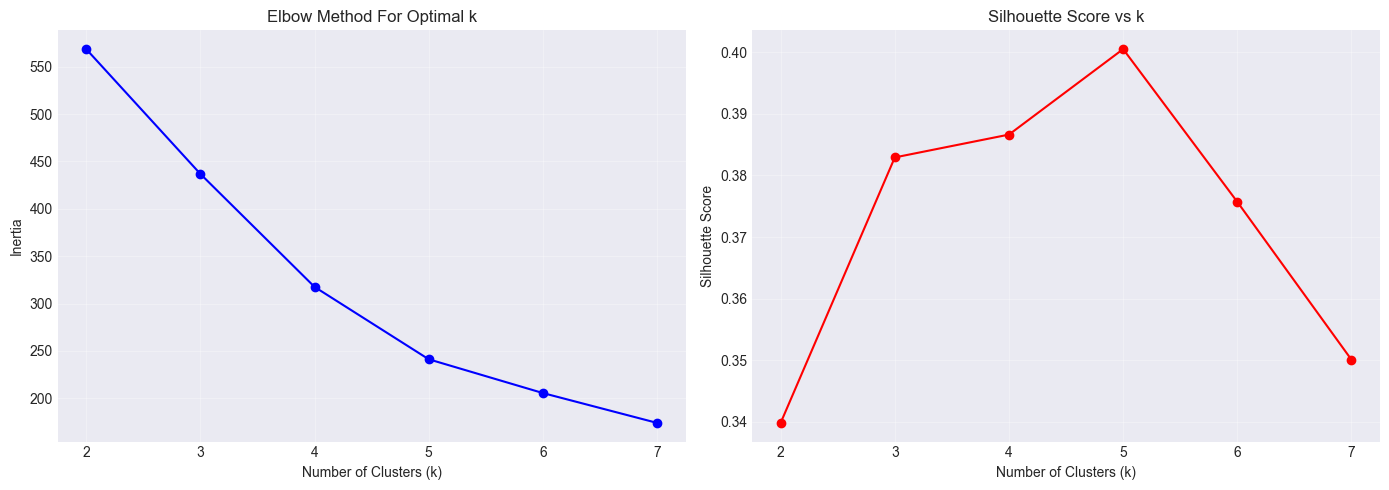


 Multi-transaction customers segmented into 4 clusters
   Single-transaction customers: 38 → Cluster 5

 Cluster Distribution:
Cluster
0    48
1    80
2     1
3    23
5    38
Name: count, dtype: int64

🔍 Multi-Transaction Cluster Characteristics:
         Avg_Amount  Num_Transactions  Total_Invested  Unique_ProductTypes  \
Cluster                                                                      
0          17773.53             12.21       204108.27                 1.96   
1          29488.92              8.85       235762.70                 1.74   
2         820498.67              3.00      2461496.00                 2.00   
3          17523.12             79.83      1273917.54                 3.57   

         Avg_Days_Between_Purchases  
Cluster                              
0                            226.21  
1                             30.33  
2                            485.00  
3                             21.22  

Reference values: Median Amount = $12,676.01, Median F

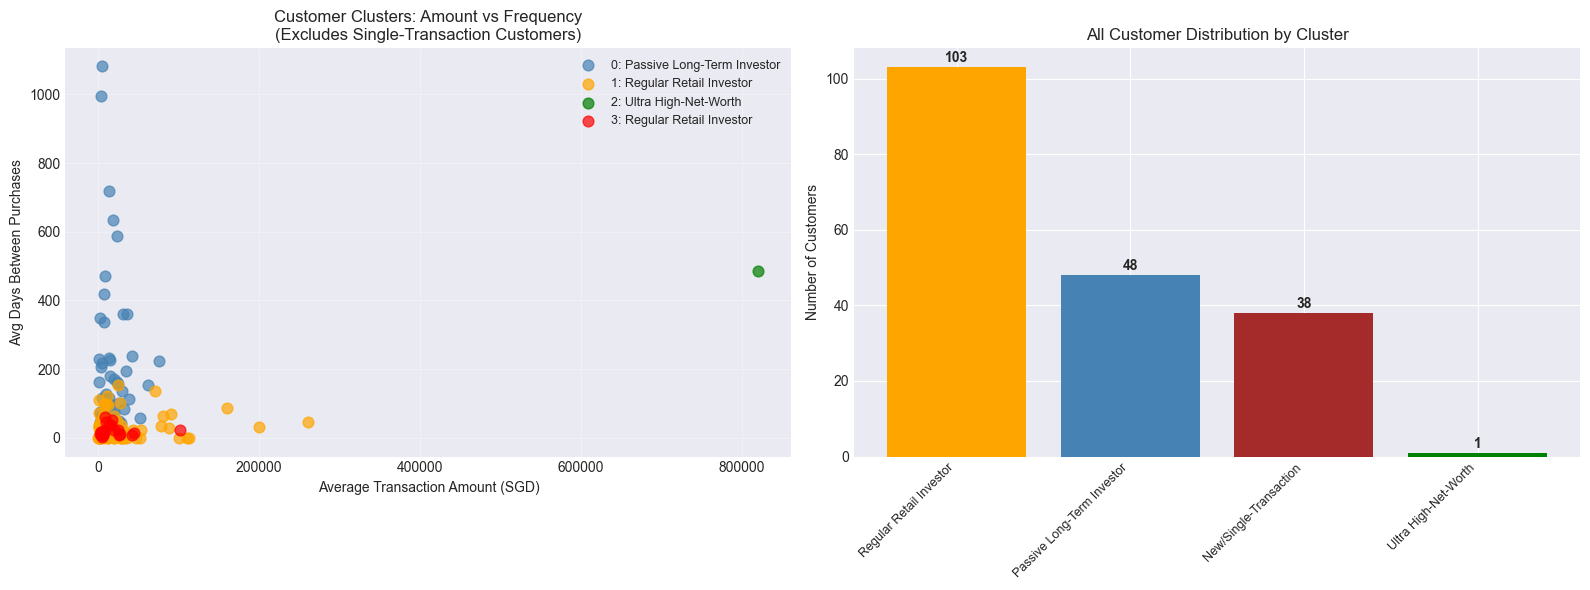


 Clustering complete!
   Multi-transaction customers: 152 (used for clustering)
   Single-transaction customers: 38 (separate group)


In [9]:
# ========================================
# CUSTOMER CLUSTERING (FIXED)
# ========================================
print(" Performing Customer Clustering...")

# FILTER OUT customers with only 1 transaction for clustering
multi_transaction_clients = client_features[client_features['Num_Transactions'] > 1].copy()
print(f" Filtering: {len(client_features)} total → {len(multi_transaction_clients)} multi-transaction customers")

# Prepare features for clustering (only multi-transaction customers)
clustering_features = multi_transaction_clients[['Avg_Amount', 'Num_Transactions', 
                                                'Unique_ProductTypes', 'Days_Active',
                                                'Avg_Days_Between_Purchases']].copy()

# Handle any remaining NaN values
clustering_features = clustering_features.fillna(clustering_features.median())

# Standardize features
scaler = StandardScaler()
clustering_features_scaled = scaler.fit_transform(clustering_features)

# Determine optimal number of clusters using elbow method
inertias = []
silhouette_scores = []
K_range = range(2, 8)  # Extended range for 5+ clusters

from sklearn.metrics import silhouette_score

for k in K_range:
    kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans.fit(clustering_features_scaled)
    inertias.append(kmeans.inertia_)
    silhouette_scores.append(silhouette_score(clustering_features_scaled, kmeans.labels_))

# Plot elbow curve
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(K_range, inertias, 'bo-')
axes[0].set_xlabel('Number of Clusters (k)')
axes[0].set_ylabel('Inertia')
axes[0].set_title('Elbow Method For Optimal k')
axes[0].grid(True, alpha=0.3)

axes[1].plot(K_range, silhouette_scores, 'ro-')
axes[1].set_xlabel('Number of Clusters (k)')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

# Perform clustering with 5 clusters (as requested)
optimal_k = 4
kmeans_final = KMeans(n_clusters=optimal_k, random_state=42, n_init=10)
multi_transaction_clients['Cluster'] = kmeans_final.fit_predict(clustering_features_scaled)

# Assign single-transaction customers to a separate cluster (cluster 5)
client_features['Cluster'] = -1  # Initialize
client_features.loc[client_features['Client'].isin(multi_transaction_clients['Client']), 'Cluster'] = \
    multi_transaction_clients.set_index('Client').loc[client_features[client_features['Client'].isin(multi_transaction_clients['Client'])]['Client'], 'Cluster'].values

# Single transaction customers get cluster 5
client_features.loc[client_features['Num_Transactions'] == 1, 'Cluster'] = 5

# Analyze clusters (only multi-transaction ones for main analysis)
print(f"\n Multi-transaction customers segmented into {optimal_k} clusters")
print(f"   Single-transaction customers: {len(client_features[client_features['Num_Transactions'] == 1])} → Cluster 5\n")

print(" Cluster Distribution:")
print(client_features['Cluster'].value_counts().sort_index())

print("\n🔍 Multi-Transaction Cluster Characteristics:")
cluster_summary = multi_transaction_clients.groupby('Cluster').agg({
    'Avg_Amount': 'mean',
    'Num_Transactions': 'mean',
    'Total_Invested': 'mean',
    'Unique_ProductTypes': 'mean',
    'Avg_Days_Between_Purchases': 'mean'
}).round(2)

print(cluster_summary)

# FIXED: Better cluster naming logic
cluster_names = {}
overall_median_amount = multi_transaction_clients['Avg_Amount'].median()
overall_median_freq = multi_transaction_clients['Avg_Days_Between_Purchases'].median()

print(f"\nReference values: Median Amount = ${overall_median_amount:,.2f}, Median Frequency = {overall_median_freq:.0f} days")

for cluster_id in range(optimal_k):
    cluster_data = multi_transaction_clients[multi_transaction_clients['Cluster'] == cluster_id]
    avg_amount = cluster_data['Avg_Amount'].mean()
    avg_frequency = cluster_data['Avg_Days_Between_Purchases'].mean()
    avg_transactions = cluster_data['Num_Transactions'].mean()
    
    print(f"\nCluster {cluster_id}: Amount=${avg_amount:,.0f}, Freq={avg_frequency:.0f}days, Txns={avg_transactions:.1f}")
    
    # CORRECTED naming logic with more specific conditions
    if avg_amount > 500000:  # Ultra high value (500k+)
        cluster_names[cluster_id] = "Ultra High-Net-Worth"
    elif avg_amount > 50000 and avg_frequency < 20:  # High amount + very frequent
        cluster_names[cluster_id] = "High-Value Active Trader"
    elif avg_amount > 50000 and avg_frequency >= 20 and avg_frequency < 100:  # High amount + moderate frequency
        cluster_names[cluster_id] = "High-Value Moderate Investor"
    elif avg_amount > 50000 and avg_frequency >= 100:  # High amount + low frequency
        cluster_names[cluster_id] = "High-Value Conservative"
    elif avg_frequency < 15:  # Low amount but very active
        cluster_names[cluster_id] = "Active Retail Trader"
    elif avg_frequency < 50:  # Low amount, moderate frequency
        cluster_names[cluster_id] = "Regular Retail Investor"
    else:  # Low amount, low frequency
        cluster_names[cluster_id] = "Passive Long-Term Investor"

# Add single-transaction cluster
cluster_names[5] = "New/Single-Transaction"

# Apply names to all customers
client_features['Cluster_Name'] = client_features['Cluster'].map(cluster_names)

print("\n Final Cluster Names:")
for cluster_id in sorted(cluster_names.keys()):
    count = len(client_features[client_features['Cluster'] == cluster_id])
    if cluster_id == 5:
        print(f"   Cluster {cluster_id}: {cluster_names[cluster_id]} ({count} customers)")
        print(f"      Single transactions only")
    else:
        cluster_data = multi_transaction_clients[multi_transaction_clients['Cluster'] == cluster_id]
        if len(cluster_data) > 0:
            avg_amt = cluster_data['Avg_Amount'].mean()
            avg_freq = cluster_data['Avg_Days_Between_Purchases'].mean()
            print(f"   Cluster {cluster_id}: {cluster_names[cluster_id]} ({count} customers)")
            print(f"      Avg Amount: ${avg_amt:,.2f} | Avg Frequency: {avg_freq:.0f} days")

# Visualize clusters (exclude single-transaction customers from scatter plot)
fig = plt.figure(figsize=(16, 6))

# 2D visualization (Amount vs Frequency) - only multi-transaction
ax1 = fig.add_subplot(121)
colors = ['steelblue', 'orange', 'green', 'red', 'purple', 'brown']
for cluster_id in range(optimal_k):
    cluster_data = multi_transaction_clients[multi_transaction_clients['Cluster'] == cluster_id]
    if len(cluster_data) > 0:
        ax1.scatter(cluster_data['Avg_Amount'], cluster_data['Avg_Days_Between_Purchases'],
                   label=f"{cluster_id}: {cluster_names[cluster_id]}", 
                   alpha=0.7, s=60, color=colors[cluster_id])

ax1.set_xlabel('Average Transaction Amount (SGD)')
ax1.set_ylabel('Avg Days Between Purchases')
ax1.set_title('Customer Clusters: Amount vs Frequency\n(Excludes Single-Transaction Customers)')
ax1.legend(fontsize=9, loc='upper right')
ax1.grid(True, alpha=0.3)

# Cluster distribution - ALL customers including single-transaction
ax2 = fig.add_subplot(122)
cluster_counts = client_features['Cluster_Name'].value_counts()

# Match colors to clusters
bar_colors = []
for name in cluster_counts.index:
    # Find which cluster this name belongs to
    for cid, cname in cluster_names.items():
        if cname == name:
            if cid < len(colors):
                bar_colors.append(colors[cid])
            else:
                bar_colors.append('gray')
            break

bars = ax2.bar(range(len(cluster_counts)), cluster_counts.values, color=bar_colors)
ax2.set_xticks(range(len(cluster_counts)))
ax2.set_xticklabels(cluster_counts.index, rotation=45, ha='right', fontsize=9)
ax2.set_ylabel('Number of Customers')
ax2.set_title('All Customer Distribution by Cluster')

# Add value labels on bars
for bar, count in zip(bars, cluster_counts.values):
    height = bar.get_height()
    ax2.text(bar.get_x() + bar.get_width()/2., height + 0.5, str(count), 
             ha='center', va='bottom', fontweight='bold')

plt.tight_layout()
plt.show()

print(f"\n Clustering complete!")
print(f"   Multi-transaction customers: {len(multi_transaction_clients)} (used for clustering)")
print(f"   Single-transaction customers: {len(client_features[client_features['Num_Transactions'] == 1])} (separate group)")

In [10]:
# Merge all features into enhanced dataframe
print(" Creating enhanced dataset...")

df_enhanced = df.merge(client_features[['Client', 'Avg_Amount', 'Median_Amount', 
                                         'Num_Transactions', 'Unique_ProductTypes', 
                                         'Favorite_ProductType', 'Days_Active',
                                         'Avg_Days_Between_Purchases', 'Cluster', 
                                         'Cluster_Name']], 
                       on='Client', how='left')

df_enhanced = df_enhanced.merge(product_type_features, on='ProductType', how='left')

# Add temporal features
df_enhanced['DayOfWeek'] = df_enhanced['Date'].dt.dayofweek
df_enhanced['Month'] = df_enhanced['Date'].dt.month
df_enhanced['Quarter'] = df_enhanced['Date'].dt.quarter

print(f" Enhanced dataset created: {df_enhanced.shape}")
print("\n Sample of enhanced data:")
df_enhanced.head()

 Creating enhanced dataset...
 Enhanced dataset created: (3171, 24)

 Sample of enhanced data:


,Client,Product,ProductType,Date,Amount,Issuer,Category,YearMonth,Avg_Amount,Median_Amount,Num_Transactions,Unique_ProductTypes,Favorite_ProductType,Days_Active,Avg_Days_Between_Purchases,Cluster,Cluster_Name,Avg_ProductType_Amount,Median_ProductType_Amount,ProductType_Popularity,Unique_Buyers,DayOfWeek,Month,Quarter
0,B1,DPMS Capital Growth IGP (Aggressive),DPMS,2021-10-29,3500.00,-,Aggressive,2021-10,1827.76375,1241.015,8,3,DPMS,307,43.857143,1,Regular Retail Investor,24952.225038,15300.00,264,89,4,10,4
1,B1,DPMS Capital Growth IGP (Aggressive),DPMS,2022-02-28,2000.00,-,Aggressive,2022-02,1827.76375,1241.015,8,3,DPMS,307,43.857143,1,Regular Retail Investor,24952.225038,15300.00,264,89,0,2,1
2,B1,DPMS Capital Growth IGP (Aggressive),DPMS,2022-06-02,5000.00,-,Aggressive,2022-06,1827.76375,1241.015,8,3,DPMS,307,43.857143,1,Regular Retail Investor,24952.225038,15300.00,264,89,3,6,2
3,B1,DigiCore Reit USD,STOCK,2022-08-18,249.85,SGX,Equity,2022-08,1827.76375,1241.015,8,3,DPMS,307,43.857143,1,Regular Retail Investor,13826.627684,5031.08,1805,91,3,8,3
4,B1,DPMS Capital Growth IGP (Aggressive),DPMS,2022-08-18,3000.00,-,Aggressive,2022-08,1827.76375,1241.015,8,3,DPMS,307,43.857143,1,Regular Retail Investor,24952.225038,15300.00,264,89,3,8,3


In [11]:
# Analyze product transitions (using actual product names)
print(" Analyzing product transitions...")

transitions = []

for client in df['Client'].unique():
    client_data = df[df['Client'] == client].sort_values('Date')
    
    for i in range(len(client_data) - 1):
        from_product = client_data.iloc[i]['Product']
        to_product = client_data.iloc[i + 1]['Product']
        from_type = client_data.iloc[i]['ProductType']
        to_type = client_data.iloc[i + 1]['ProductType']
        
        # Track all product-to-product transitions (including same type)
        if from_product != to_product:
            transitions.append({
                'Client': client,
                'From_Product': from_product,
                'To_Product': to_product,
                'From_ProductType': from_type,
                'To_ProductType': to_type
            })

transitions_df = pd.DataFrame(transitions)

print(f" Identified {len(transitions_df)} product transitions")

# Calculate transition probabilities BY PRODUCT TYPE
if len(transitions_df) > 0:
    # Group by product type transitions
    transition_counts = transitions_df.groupby(['From_ProductType', 'To_ProductType']).size().reset_index(name='Count')
    total_from = transitions_df.groupby('From_ProductType').size().reset_index(name='Total')
    
    transition_probs = transition_counts.merge(total_from, on='From_ProductType')
    transition_probs['Probability'] = transition_probs['Count'] / transition_probs['Total']
    transition_probs = transition_probs.sort_values('Probability', ascending=False)
    
    print("\n Top 15 Product Type Transitions:")
    print(transition_probs[['From_ProductType', 'To_ProductType', 'Count', 'Probability']].head(15))
    
    # Also show sample of actual product transitions
    print("\n Sample Product-Level Transitions:")
    sample_transitions = transitions_df[['From_Product', 'To_Product', 'From_ProductType', 'To_ProductType']].head(10)
    print(sample_transitions)
else:
    transition_probs = pd.DataFrame(columns=['From_ProductType', 'To_ProductType', 'Count', 'Probability'])
    print(" No transitions found")

 Analyzing product transitions...
 Identified 2281 product transitions

 Top 15 Product Type Transitions:
   From_ProductType To_ProductType  Count  Probability
18            STOCK          STOCK   1090     0.831426
0              BOND           BOND    145     0.771277
24               UT             UT    203     0.738182
12              ETF            ETF    149     0.425714
13              ETF          STOCK    144     0.411429
6              DPMS           DPMS     51     0.324841
8              DPMS          STOCK     38     0.242038
7              DPMS            ETF     35     0.222930
9              DPMS             UT     25     0.159236
3              BOND          STOCK     21     0.111702
17            STOCK            ETF    141     0.107551
23               UT          STOCK     27     0.098182
21               UT           DPMS     25     0.090909
11              ETF           DPMS     31     0.088571
1              BOND           DPMS     12     0.063830

 Sample Produ

 Performing market basket analysis...
 Found 31 frequent product type combinations
 Generated 115 association rules


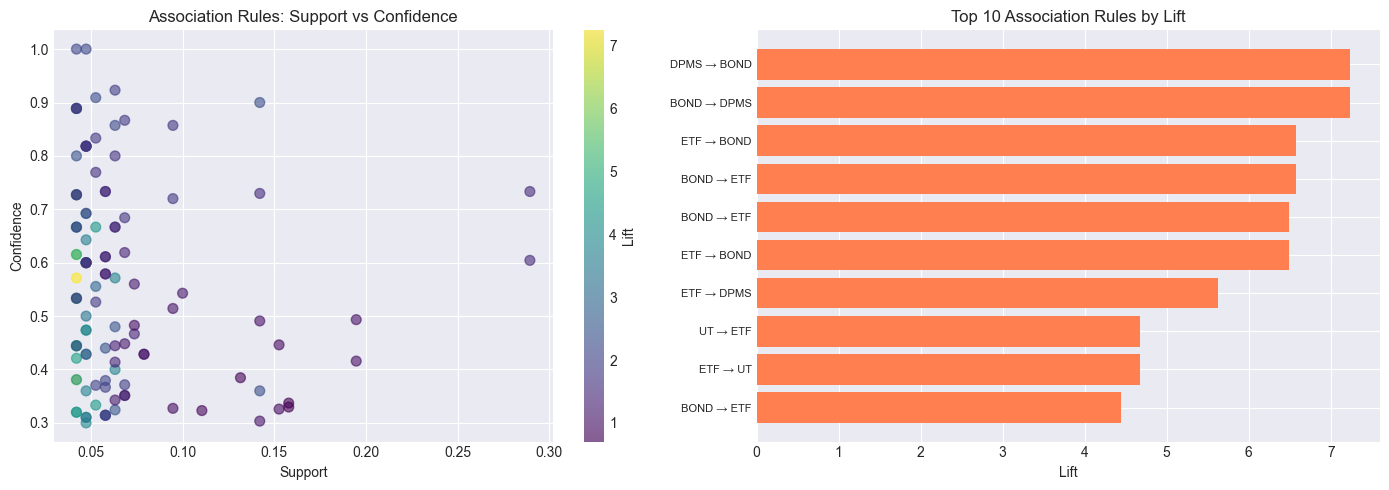

In [12]:
# Market basket analysis using product types
print(" Performing market basket analysis...")

# Create baskets (list of product types per client)
baskets = df.groupby('Client')['ProductType'].apply(list).values.tolist()

# Encode transactions
te = TransactionEncoder()
te_ary = te.fit(baskets).transform(baskets)
basket_df = pd.DataFrame(te_ary, columns=te.columns_)

# Apply Apriori algorithm
frequent_itemsets = apriori(basket_df, min_support=0.02, use_colnames=True)

if len(frequent_itemsets) > 0:
    print(f" Found {len(frequent_itemsets)} frequent product type combinations")
    
    # Generate association rules
    rules = association_rules(frequent_itemsets, metric="confidence", min_threshold=0.3)
    rules = rules.sort_values('lift', ascending=False)
    
    print(f" Generated {len(rules)} association rules")
    
    # Visualize
    fig, axes = plt.subplots(1, 2, figsize=(14, 5))
    
    # Support vs Confidence
    scatter = axes[0].scatter(rules['support'], rules['confidence'], 
                             c=rules['lift'], cmap='viridis', alpha=0.6, s=50)
    axes[0].set_xlabel('Support')
    axes[0].set_ylabel('Confidence')
    axes[0].set_title('Association Rules: Support vs Confidence')
    plt.colorbar(scatter, ax=axes[0], label='Lift')
    
    # Top rules by lift
    top_rules = rules.head(10)
    axes[1].barh(range(len(top_rules)), top_rules['lift'].values, color='coral')
    axes[1].set_yticks(range(len(top_rules)))
    axes[1].set_yticklabels([f"{list(r['antecedents'])[0]} → {list(r['consequents'])[0]}" 
                             for _, r in top_rules.iterrows()], fontsize=8)
    axes[1].set_xlabel('Lift')
    axes[1].set_title('Top 10 Association Rules by Lift')
    axes[1].invert_yaxis()
    
    plt.tight_layout()
    plt.show()
    
    # print("\n Top 10 Association Rules:")
    # for idx, row in rules.head(10).iterrows():
    #     print(f"   {list(row['antecedents'])} → {list(row['consequents'])}")
    #     print(f"   Support: {row['support']:.3f} | Confidence: {row['confidence']:.3f} | Lift: {row['lift']:.3f}\n")
else:
    rules = pd.DataFrame()
    print(" No frequent itemsets found with min_support=0.02")

 Training transaction amount prediction model...

 Model Performance:
   MAE:  $11,846.72
   RMSE: $44,402.35
   R²:   0.4039
   MAPE: 181.93%


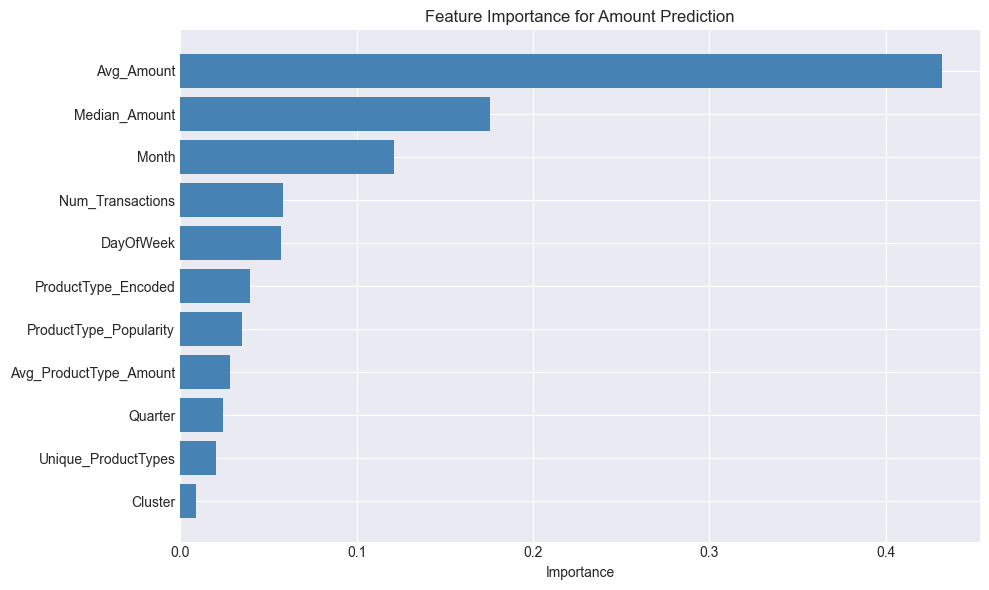


 Amount prediction model trained!


In [13]:
# Build model to predict transaction amounts
print(" Training transaction amount prediction model...")

# Prepare features
le = LabelEncoder()
df_enhanced['ProductType_Encoded'] = le.fit_transform(df_enhanced['ProductType'])

amount_features = df_enhanced[['Avg_Amount', 'Median_Amount', 'Num_Transactions',
                               'Unique_ProductTypes', 'Avg_ProductType_Amount',
                               'ProductType_Popularity', 'DayOfWeek', 'Month', 
                               'Quarter', 'ProductType_Encoded', 'Cluster']].copy()

amount_features = amount_features.fillna(amount_features.median())

X = amount_features
y = df_enhanced['Amount']

# Split data
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

# Train model
rf_amount = RandomForestRegressor(n_estimators=100, random_state=42, max_depth=10)
rf_amount.fit(X_train, y_train)

# Predictions
y_pred = rf_amount.predict(X_test)

# Evaluate
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r2 = r2_score(y_test, y_pred)
mape = np.mean(np.abs((y_test - y_pred) / y_test)) * 100

print(f"\n Model Performance:")
print(f"   MAE:  ${mae:,.2f}")
print(f"   RMSE: ${rmse:,.2f}")
print(f"   R²:   {r2:.4f}")
print(f"   MAPE: {mape:.2f}%")

# Feature importance
feature_importance = pd.DataFrame({
    'Feature': amount_features.columns,
    'Importance': rf_amount.feature_importances_
}).sort_values('Importance', ascending=False)

plt.figure(figsize=(10, 6))
plt.barh(feature_importance['Feature'], feature_importance['Importance'], color='steelblue')
plt.xlabel('Importance')
plt.title('Feature Importance for Amount Prediction')
plt.gca().invert_yaxis()
plt.tight_layout()
plt.show()

print("\n Amount prediction model trained!")

In [14]:
# Predict next purchase timing
print(" Predicting next purchase timing...")

df_sorted = df.sort_values(['Client', 'Date'])
df_sorted['Days_Since_Last'] = df_sorted.groupby('Client')['Date'].diff().dt.days

next_purchase_predictions = []

for client in client_features['Client'].unique():
    client_data = df_sorted[df_sorted['Client'] == client]
    
    if len(client_data) >= 1:
        last_transaction_date = client_data['Date'].max()
        
        if len(client_data) >= 2:
            avg_interval = client_data['Days_Since_Last'].dropna().mean()
            median_interval = client_data['Days_Since_Last'].dropna().median()
        else:
            avg_interval = 30
            median_interval = 30
        
        predicted_next_date = last_transaction_date + timedelta(days=median_interval)
        
        next_purchase_predictions.append({
            'Client': client,
            'Last_Transaction_Date': last_transaction_date,
            'Avg_Days_Between': avg_interval,
            'Median_Days_Between': median_interval,
            'Predicted_Next_Purchase_Date': predicted_next_date
        })

timing_predictions = pd.DataFrame(next_purchase_predictions)

print(f" Timing predictions generated for {len(timing_predictions)} clients")
print("\n Sample predictions:")
timing_predictions.head(10)

 Predicting next purchase timing...
 Timing predictions generated for 190 clients

 Sample predictions:


,Client,Last_Transaction_Date,Avg_Days_Between,Median_Days_Between,Predicted_Next_Purchase_Date
0,B1,2022-09-01,43.857143,7.0,2022-09-08
1,B10,2025-09-25,14.939394,6.0,2025-10-01
2,B100,2022-08-18,33.750000,22.0,2022-09-09
3,B101,2022-04-08,30.000000,30.0,2022-05-08
4,B102,2024-04-01,360.000000,360.0,2025-03-27
5,B103,2025-04-01,361.666667,365.0,2026-04-01
6,B104,2022-06-23,65.000000,65.0,2022-08-27
7,B105,2025-04-10,1081.000000,1081.0,2028-03-26
8,B106,2022-05-06,30.000000,30.0,2022-06-05
9,B107,2022-05-12,30.000000,30.0,2022-06-11


In [15]:
# ========================================
# FIND SIMILAR CUSTOMERS
# ========================================
print(" Building similar customers functionality...")

def find_similar_customers(target_client, top_n=10):
    """
    Find customers similar to the target customer based on:
    1. Same cluster
    2. Similar spending patterns
    3. Similar product type preferences
    """
    
    # Get target customer info
    target_info = client_features[client_features['Client'] == target_client].iloc[0]
    target_cluster = target_info['Cluster']
    
    # Get customers from same cluster (excluding target)
    same_cluster = client_features[
        (client_features['Cluster'] == target_cluster) & 
        (client_features['Client'] != target_client)
    ].copy()
    
    if len(same_cluster) == 0:
        print(f" No other customers in cluster {target_cluster}")
        return pd.DataFrame()
    
    # Calculate similarity scores
    similarity_scores = []
    
    # Get target's product type preferences
    target_products = set(df[df['Client'] == target_client]['ProductType'].unique())
    
    for _, customer in same_cluster.iterrows():
        customer_id = customer['Client']
        customer_products = set(df[df['Client'] == customer_id]['ProductType'].unique())
        
        # Jaccard similarity for product types
        jaccard_sim = len(target_products & customer_products) / len(target_products | customer_products)
        
        # Spending similarity (inverse of normalized difference)
        spending_diff = abs(target_info['Avg_Amount'] - customer['Avg_Amount'])
        max_spending = max(target_info['Avg_Amount'], customer['Avg_Amount'])
        spending_sim = 1 - (spending_diff / max_spending) if max_spending > 0 else 1
        
        # Frequency similarity
        freq_diff = abs(target_info['Avg_Days_Between_Purchases'] - customer['Avg_Days_Between_Purchases'])
        max_freq = max(target_info['Avg_Days_Between_Purchases'], customer['Avg_Days_Between_Purchases'])
        freq_sim = 1 - (freq_diff / max_freq) if max_freq > 0 else 1
        
        # Combined similarity (weighted average)
        combined_similarity = (0.5 * jaccard_sim + 0.3 * spending_sim + 0.2 * freq_sim)
        
        similarity_scores.append({
            'Client': customer_id,
            'Similarity_Score': combined_similarity,
            'Jaccard_Similarity': jaccard_sim,
            'Spending_Similarity': spending_sim,
            'Frequency_Similarity': freq_sim,
            'Avg_Amount': customer['Avg_Amount'],
            'Num_Transactions': customer['Num_Transactions']
        })
    
    # Sort by similarity
    similar_customers_df = pd.DataFrame(similarity_scores).sort_values(
        'Similarity_Score', ascending=False
    ).head(top_n)
    
    return similar_customers_df

# Test the function
test_client = client_features['Client'].iloc[0]
similar_customers = find_similar_customers(test_client, top_n=10)

print(f"\n Similar customers function created!")
print(f"\n Top 10 customers similar to {test_client}:")
print(similar_customers)

 Building similar customers functionality...

 Similar customers function created!

 Top 10 customers similar to B1:
   Client  Similarity_Score  Jaccard_Similarity  Spending_Similarity  \
33   B177          0.704635            0.666667             0.812047   
60    B25          0.664224            1.000000             0.095859   
5    B119          0.656380            1.000000             0.184566   
77    B94          0.618183            1.000000             0.059523   
76    B93          0.613062            1.000000             0.042455   
0    B100          0.597883            0.666667             0.368804   
64    B61          0.551727            0.666667             0.176316   
73    B80          0.547573            0.666667             0.174503   
19    B15          0.531879            0.666667             0.426000   
62     B5          0.530025            0.666667             0.064326   

    Frequency_Similarity    Avg_Amount  Num_Transactions  
33              0.638436   1484

In [16]:
# Enhanced Recommendation Engine
print(" Building enhanced recommendation engine...")

def get_recommendations_for_client(client_id):
    """Generate recommendations using multiple signals"""
    
    client_info = client_features[client_features['Client'] == client_id].iloc[0]
    last_product_type = df[df['Client'] == client_id].sort_values('Date').iloc[-1]['ProductType']
    
    # Signal 1: Sequential patterns
    sequential_rec = None
    seq_conf = 0
    next_candidates = transition_probs[transition_probs['From_ProductType'] == last_product_type]
    if not next_candidates.empty:
        sequential_rec = next_candidates.iloc[0]['To_ProductType']
        seq_conf = next_candidates.iloc[0]['Probability']
    
    # Signal 2: Similar customers
    similar_customers = find_similar_customers(client_id, top_n=10)
    similar_rec = None
    sim_conf = 0
    
    if len(similar_customers) > 0:
        similar_client_ids = similar_customers['Client'].tolist()
        similar_products = df[df['Client'].isin(similar_client_ids)]['ProductType'].value_counts()
        client_products = set(df[df['Client'] == client_id]['ProductType'])
        
        for prod_type in similar_products.index:
            if prod_type not in client_products:
                similar_rec = prod_type
                buyers = df[df['Client'].isin(similar_client_ids) & 
                          (df['ProductType'] == prod_type)]['Client'].nunique()
                sim_conf = buyers / len(similar_customers)
                break
    
    # Combine with weighted voting
    recommendations = {}
    if sequential_rec:
        recommendations[sequential_rec] = recommendations.get(sequential_rec, 0) + (0.4 * seq_conf)
    if similar_rec:
        recommendations[similar_rec] = recommendations.get(similar_rec, 0) + (0.6 * sim_conf)
    
    # Fallback: Popular products not yet bought
    if not recommendations:
        all_products = df['ProductType'].value_counts()
        client_products = set(df[df['Client'] == client_id]['ProductType'])
        for prod in all_products.index:
            if prod not in client_products:
                recommendations[prod] = 0.3
                break
    
    # Get top recommendation
    if recommendations:
        top_rec = max(recommendations.items(), key=lambda x: x[1])
        return {
            'recommended_type': top_rec[0],
            'confidence': top_rec[1],
            'sequential_rec': sequential_rec,
            'similar_customers_rec': similar_rec
        }
    
    return None

# Test
test_rec = get_recommendations_for_client(client_features['Client'].iloc[0])
print(f" Recommendation engine ready!")
print(f"\n Sample recommendation: {test_rec}")

 Building enhanced recommendation engine...
 Recommendation engine ready!

 Sample recommendation: {'recommended_type': 'ETF', 'confidence': 0.1702857142857143, 'sequential_rec': 'ETF', 'similar_customers_rec': None}


In [20]:
# Generate recommendations for all clients
print(" Generating recommendations for all clients...")

all_recommendations = []

for client in client_features['Client'].unique():
    rec = get_recommendations_for_client(client)
    
    if rec:
        client_info = client_features[client_features['Client'] == client].iloc[0]
        last_product_type = df[df['Client'] == client].sort_values('Date').iloc[-1]['ProductType']
        
        # Predict amount
        client_row = df_enhanced[df_enhanced['Client'] == client].iloc[-1]
        features_for_pred = amount_features.iloc[df_enhanced[df_enhanced['Client'] == client].index[-1]].values.reshape(1, -1)
        predicted_amount = rf_amount.predict(features_for_pred)[0]
        
        # Get timing
        timing_info = timing_predictions[timing_predictions['Client'] == client]
        predicted_date = timing_info.iloc[0]['Predicted_Next_Purchase_Date'] if not timing_info.empty else pd.Timestamp.now() + timedelta(days=30)
        
        all_recommendations.append({
            'Client': client,
            'Cluster': client_info['Cluster_Name'],
            'Current_ProductType': last_product_type,
            'Recommended_ProductType': rec['recommended_type'],
            'Confidence': f"{rec['confidence']:.2%}",
            'Predicted_Amount_SGD': f"{predicted_amount:,.2f}",
            'Predicted_Purchase_Date': predicted_date.date(),
            'Avg_Historical_Amount': f"{client_info['Avg_Amount']:,.2f}",
            'Total_Transactions': int(client_info['Num_Transactions'])
        })

recommendations_df = pd.DataFrame(all_recommendations)
print(f"\n Generated recommendations for {len(recommendations_df)} clients")
recommendations_df.head(50)

 Generating recommendations for all clients...
 No other customers in cluster 2

 Generated recommendations for 190 clients


,Client,Cluster,Current_ProductType,Recommended_ProductType,Confidence,Predicted_Amount_SGD,Predicted_Purchase_Date,Avg_Historical_Amount,Total_Transactions
0,B1,Regular Retail Investor,ETF,ETF,17.03%,"1,069.76",2022-09-08,"1,827.76",8
1,B10,Regular Retail Investor,STOCK,STOCK,33.26%,"60,810.63",2025-10-01,"44,893.02",100
2,B100,Regular Retail Investor,DPMS,STOCK,36.00%,"1,001.97",2022-09-09,674.09,5
3,B101,New/Single-Transaction,ETF,DPMS,18.00%,"10,735.28",2022-05-08,"10,074.42",1
4,B102,Passive Long-Term Investor,DPMS,DPMS,12.99%,"33,659.16",2025-03-27,"35,301.87",3
5,B103,Passive Long-Term Investor,DPMS,DPMS,12.99%,"33,126.90",2026-04-01,"30,325.69",4
6,B104,Regular Retail Investor,BOND,BOND,30.85%,"114,122.63",2022-08-27,"80,096.20",2
7,B105,Passive Long-Term Investor,STOCK,STOCK,33.26%,"4,167.19",2028-03-26,"4,376.98",2
8,B106,New/Single-Transaction,STOCK,STOCK,33.26%,"27,049.19",2022-06-05,"27,577.00",1
9,B107,New/Single-Transaction,DPMS,DPMS,12.99%,"48,156.02",2022-06-11,"50,000.00",1


C:\Users\rudra\AppData\Local\Temp\ipykernel_17112\4200937694.py:35: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = plt.cm.get_cmap("tab20", len(unique_types))


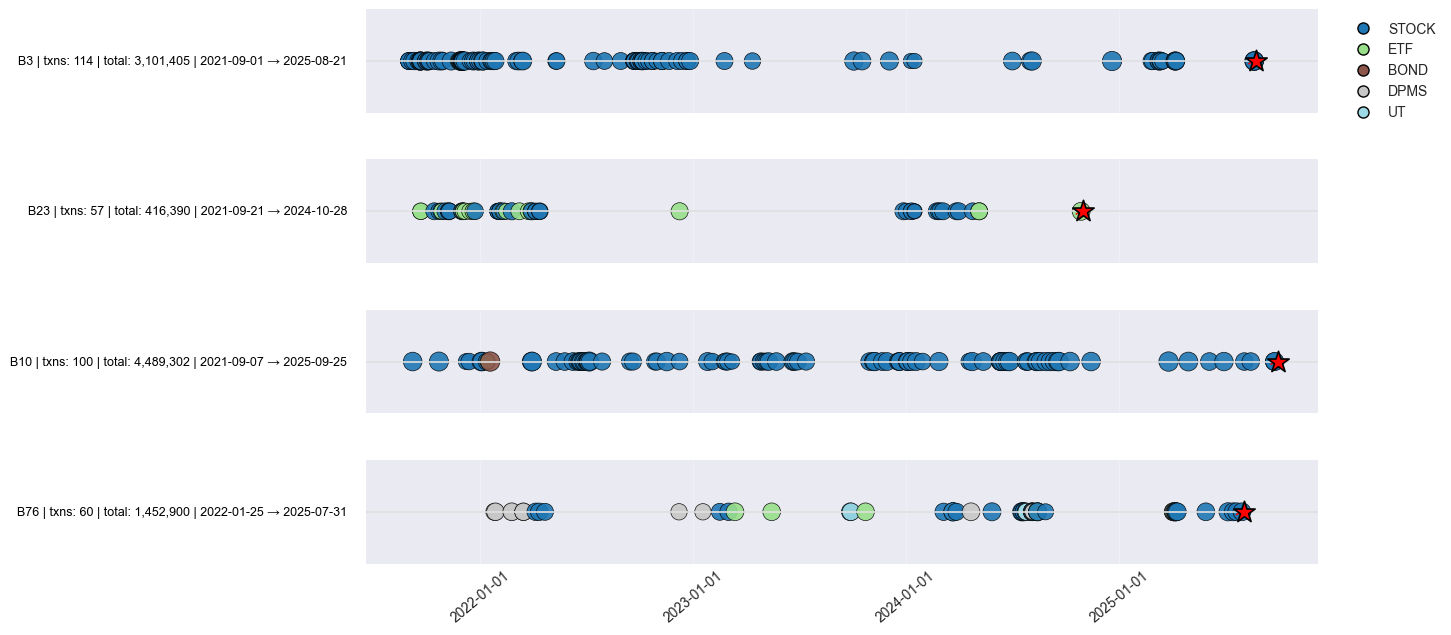

In [18]:
def plot_timeline_with_similars(df,
                                target_client,
                                n_similar=3,
                                similar_clients_list=None,
                                show_similar=True,
                                figsize_per_row=(14, 1.8)):
    """
    Improved version:
    - Text moved outside the plot area to prevent overlaps
    - Automatic left margin for labels
    - Slight vertical spacing between subplots
    """
    df = df.copy()
    df["Date"] = pd.to_datetime(df["Date"])

    # --- get similar customers ---
    if similar_clients_list is None and show_similar:
        try:
            similars_df = find_similar_customers(target_client, top_n=n_similar)
            similar_clients_list = similars_df["Client"].head(n_similar).tolist()
        except Exception:
            similar_clients_list = []
    rows = [target_client] + (similar_clients_list or [])
    if not rows:
        print("No clients to plot.")
        return

    # --- subset data ---
    plotted_df = df[df["Client"].isin(rows)]
    if plotted_df.empty:
        print("No transactions found for selected clients.")
        return

    unique_types = plotted_df["ProductType"].dropna().unique()
    cmap = plt.cm.get_cmap("tab20", len(unique_types))
    color_map = {pt: cmap(i) for i, pt in enumerate(unique_types)}

    # --- dynamic x limits ---
    min_date, max_date = plotted_df["Date"].min(), plotted_df["Date"].max()
    pad = pd.Timedelta(days=max(7, (max_date - min_date).days * 0.05))
    x_min, x_max = min_date - pad, max_date + pad

    n_rows = len(rows)
    fig, axes = plt.subplots(
        n_rows, 1, figsize=(figsize_per_row[0], figsize_per_row[1] * n_rows),
        sharex=True, gridspec_kw={'left': 0.22, 'hspace': 0.45}
    )
    if n_rows == 1:
        axes = [axes]

    # --- plotting loop ---
    for ax, client in zip(axes, rows):
        cdata = df[df["Client"] == client].sort_values("Date")
        if cdata.empty:
            ax.text(0.5, 0.5, f"{client} — No transactions", ha="center", va="center")
            continue

        sizes = (np.log1p(cdata["Amount"].abs()) * 14) + 20
        colors = [color_map.get(pt, "gray") for pt in cdata["ProductType"]]
        y_level = 0.5

        # baseline + points
        ax.hlines(y=y_level, xmin=x_min, xmax=x_max, color="#e0e0e0", lw=1.2)
        ax.scatter(cdata["Date"], [y_level]*len(cdata),
                   s=sizes, c=colors, edgecolors="black", lw=0.5, alpha=0.9)

        # summary text OUTSIDE plot (to left margin)
        total_amt = cdata["Amount"].sum()
        label = (f"{client} | txns: {len(cdata)} | "
                 f"total: {total_amt:,.0f} | "
                 f"{cdata['Date'].min().date()} → {cdata['Date'].max().date()}")
        ax.text(-0.02, y_level, label, transform=ax.transAxes,
                ha="right", va="center", fontsize=9, color="black")

        # predicted next purchase marker (if available)
        try:
            if "timing_predictions" in globals():
                pred_row = timing_predictions[timing_predictions["Client"] == client]
                if not pred_row.empty:
                    pred_date = pd.to_datetime(pred_row.iloc[0]["Predicted_Next_Purchase_Date"])
                    last_real = cdata["Date"].max()
                    ax.scatter(pred_date, y_level, marker="*", s=260, c="red",
                               edgecolors="black", lw=1.2, zorder=5)
                    ax.annotate("", xy=(pred_date, y_level), xytext=(last_real, y_level),
                                arrowprops=dict(arrowstyle="->", color="red", lw=1.1))
        except Exception:
            pass

        ax.set_yticks([])
        ax.set_ylim(0, 1)
        ax.grid(axis="x", alpha=0.25)
        ax.set_xlim(x_min, x_max)

    # bottom x-axis formatting
    locator = AutoDateLocator(minticks=4, maxticks=8)
    axes[-1].xaxis.set_major_locator(locator)
    axes[-1].xaxis.set_major_formatter(DateFormatter("%Y-%m-%d"))
    plt.xticks(rotation=40)

    # legend on top-right outside
    legend_elems = [
        mlines.Line2D([], [], marker="o", linestyle="",
                      markerfacecolor=color_map[pt], markeredgecolor="black",
                      markersize=8, label=pt)
        for pt in unique_types
    ]
    axes[0].legend(handles=legend_elems, bbox_to_anchor=(1.02, 1),
                   loc="upper left", frameon=False)

    plt.show()


# Example call
plot_timeline_with_similars(df, target_client="B3", n_similar=3)

In [19]:
# Final Summary Dashboard
print("\n" + "="*70)
print(" ANALYSIS SUMMARY")
print("="*70)

print(f"\n Dataset: {len(df)} transactions | {df['Client'].nunique()} clients")
print(f" Customer Clusters: {optimal_k} segments")
for cluster_id, name in cluster_names.items():
    count = len(client_features[client_features['Cluster'] == cluster_id])
    print(f"   - {name}: {count} customers")

print(f"\n Product Type Transitions: {len(transitions_df)} identified")
print(f" Association Rules: {len(rules) if len(rules) > 0 else 0} rules")
print(f"\n Amount Prediction Model: R² = {r2:.4f}, MAE = ${mae:,.2f}")
print(f" Timing Predictions: {len(timing_predictions)} clients")
print(f" Recommendations Generated: {len(recommendations_df)} clients")

print("\n" + "="*70)
print(" All enhancements complete! Ready for analysis.")
print("="*70)


 ANALYSIS SUMMARY

 Dataset: 3171 transactions | 190 clients
 Customer Clusters: 4 segments
   - Passive Long-Term Investor: 48 customers
   - Regular Retail Investor: 80 customers
   - Ultra High-Net-Worth: 1 customers
   - Regular Retail Investor: 23 customers
   - New/Single-Transaction: 38 customers

 Product Type Transitions: 2281 identified
 Association Rules: 115 rules

 Amount Prediction Model: R² = 0.4039, MAE = $11,846.72
 Timing Predictions: 190 clients
 Recommendations Generated: 190 clients

 All enhancements complete! Ready for analysis.
